# Treinamento e avaliação do BKT

Este notebook documenta e executa o fluxo de *Bayesian Knowledge Tracing* (BKT) usado no Fake News Fact Checker. O código do motor é importado diretamente de `backend/app/bkt/engine.py`; o ajuste de parâmetros apresentado aqui é uma etapa de calibração experimental que ainda não faz parte do backend.

**Limite dos dados locais:** o banco `backend/fact_check.db` foi verificado e contém zero respostas. Os CSVs em `EDA/datasets/` são notícias rotuladas, não sequências de respostas por aprendiz. Assim, na ausência de um CSV real em `backend/data/bkt_responses.csv`, este notebook gera dados sintéticos para demonstrar o pipeline. Métricas sintéticas não são evidência de desempenho com usuários reais e o artefato de demonstração não deve ser implantado.

Para calibração real, forneça um CSV com as colunas `user_id`, `skill_code`, `correct`, `created_at`. Cada linha deve representar uma resposta; não inclua dados pessoais identificáveis.

## Decisões técnicas registradas

- `BKTEngine` é stateless e independente de banco/API. O `BKTManager` encaminha a resposta a um dos quatro trackers (`SOURCE`, `EVIDENCE`, `CONTEXT`, `VISUAL`); hoje todos usam os mesmos valores: `p_init=0.30`, `p_guess=0.20`, `p_slip=0.05`, `p_transition=0.10`.
- Em cada observação, o motor calcula o posterior Bayesiano para correta/incorreta e depois aplica a transição de aprendizagem. `AnswerService.process_answer` chama o manager e persiste a resposta e o novo estado de domínio na mesma transação.
- A seleção adaptativa do MVP prioriza a habilidade com menor domínio estimado. Não há ajuste estatístico dos parâmetros de BKT no fluxo da API; os parâmetros acima são defaults codificados, não resultados de treinamento.
- Esta calibração estima quatro parâmetros globais com máxima verossimilhança em sequências agrupadas por aprendiz/habilidade. A validação mantém a ordem temporal, reservando o sufixo de cada sequência como holdout.

Referências no repositório: `backend/app/bkt/engine.py`, `backend/app/bkt/manager.py`, `backend/app/bkt/*_tracker.py`, `backend/app/services/answer.py`, `backend/app/adaptation/question_selector.py`, `ARCHITECTURE.md`, `backend/tests/bkt/test_engine.py` e `backend/tests/bkt/test_manager.py`. Os testes unitários verificam fórmulas, limites de probabilidade e roteamento entre trackers.

In [2]:
%pip install numpy pandas scipy matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path
import json
import pickle
import sqlite3
import sys
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name != 'notebooks':
    candidate = Path.cwd().resolve() / 'backend' / 'notebooks'
    NOTEBOOK_DIR = candidate if candidate.exists() else NOTEBOOK_DIR
REPO_ROOT = NOTEBOOK_DIR.parents[1] if NOTEBOOK_DIR.name == 'notebooks' else Path.cwd().resolve()
BACKEND_DIR = REPO_ROOT / 'backend'
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))
from app.bkt.engine import BKTEngine

print('Raiz do repositório:', REPO_ROOT)
print('Versões:', {'numpy': np.__version__, 'pandas': pd.__version__})
print('Parâmetros do motor:', BKTEngine().get_parameters())

Matplotlib is building the font cache; this may take a moment.


Raiz do repositório: /Users/aluno1/Fake_News_Fact_Checker
Versões: {'numpy': '2.5.3', 'pandas': '3.0.6'}
Parâmetros do motor: {'p_guess': 0.2, 'p_slip': 0.05, 'p_transition': 0.1, 'p_init': 0.3}


## Carregamento dos dados

A fonte prioritária é `backend/data/bkt_responses.csv`; em seguida, o notebook tenta ler `backend/fact_check.db` em modo somente leitura. O banco é consultado juntando `answers`, `questions` e `skills`, sem gravar ou alterar nada. Somente se ambas as fontes estiverem vazias é criado um conjunto sintético determinístico para demonstrar a execução.

In [3]:
REQUIRED_COLUMNS = {'user_id', 'skill_code', 'correct', 'created_at'}
CSV_PATH = BACKEND_DIR / 'data' / 'bkt_responses.csv'
DB_PATH = BACKEND_DIR / 'fact_check.db'

def normalize_interactions(frame):
    missing = REQUIRED_COLUMNS - set(frame.columns)
    if missing:
        raise ValueError(f'Colunas ausentes: {sorted(missing)}')
    frame = frame[list(REQUIRED_COLUMNS)].copy()
    truth_values = {'1': True, 'true': True, 't': True, 'yes': True, '0': False, 'false': False, 'f': False, 'no': False}
    if frame['correct'].dtype != bool:
        frame['correct'] = frame['correct'].map(lambda value: truth_values.get(str(value).strip().lower(), value))
    if not frame['correct'].map(lambda value: isinstance(value, (bool, np.bool_))).all():
        raise ValueError('A coluna correct deve conter valores booleanos ou 0/1.')
    frame['correct'] = frame['correct'].astype(int)
    frame['user_id'] = frame['user_id'].astype(str)
    frame['skill_code'] = frame['skill_code'].astype(str).str.upper()
    frame['created_at'] = pd.to_datetime(frame['created_at'], errors='coerce', utc=True)
    frame = frame.dropna(subset=['user_id', 'skill_code', 'created_at'])
    return frame.sort_values(['user_id', 'skill_code', 'created_at'], kind='stable').reset_index(drop=True)

def load_real_interactions():
    if CSV_PATH.exists():
        csv_data = normalize_interactions(pd.read_csv(CSV_PATH))
        if not csv_data.empty:
            return csv_data, f'csv:{CSV_PATH.relative_to(REPO_ROOT)}'
    if DB_PATH.exists():
        try:
            with sqlite3.connect(f'{DB_PATH.as_uri()}?mode=ro', uri=True) as connection:
                db_data = pd.read_sql_query('''
                    SELECT a.user_id, s.code AS skill_code, a.correct, a.created_at
                    FROM answers AS a
                    JOIN questions AS q ON q.id = a.question_id
                    JOIN skills AS s ON s.id = q.skill_id
                ''', connection)
            db_data = normalize_interactions(db_data)
            if not db_data.empty:
                return db_data, f'sqlite:{DB_PATH.relative_to(REPO_ROOT)}'
        except (sqlite3.Error, pd.errors.DatabaseError) as error:
            print('Banco indisponível para leitura:', error)
    return None, None

interactions, DATA_SOURCE = load_real_interactions()
IS_REAL_DATA = interactions is not None

if not IS_REAL_DATA:
    rng = np.random.default_rng(20261009)
    demo_engine = BKTEngine()
    demo_rows = []
    skills = ['SOURCE', 'EVIDENCE', 'CONTEXT', 'VISUAL']
    for user_number in range(120):
        for skill_code in skills:
            hidden_mastery = float(np.clip(rng.normal(0.30, 0.08), 0.05, 0.70))
            for attempt in range(16):
                probability_correct = hidden_mastery * (1 - demo_engine.p_slip) + (1 - hidden_mastery) * demo_engine.p_guess
                correct = bool(rng.random() < probability_correct)
                demo_rows.append({'user_id': f'demo-{user_number:03d}', 'skill_code': skill_code, 'correct': correct, 'created_at': pd.Timestamp('2026-01-01', tz='UTC') + pd.Timedelta(days=attempt)})
                hidden_mastery = demo_engine.update(hidden_mastery, correct)
    interactions = normalize_interactions(pd.DataFrame(demo_rows))
    DATA_SOURCE = 'synthetic_demo (seed=20261009)'
    print('AVISO: sem respostas reais. A base abaixo é sintética e serve somente para demonstrar o pipeline.')
else:
    print('Fonte real carregada:', DATA_SOURCE)

print(f'{len(interactions):,} respostas; {interactions.user_id.nunique()} usuários; {interactions.skill_code.nunique()} habilidades; origem real={IS_REAL_DATA}')
interactions.head()

AVISO: sem respostas reais. A base abaixo é sintética e serve somente para demonstrar o pipeline.
7,680 respostas; 120 usuários; 4 habilidades; origem real=False


,skill_code,correct,created_at,user_id
0,CONTEXT,0,2026-01-01 00:00:00+00:00,demo-000
1,CONTEXT,0,2026-01-02 00:00:00+00:00,demo-000
2,CONTEXT,0,2026-01-03 00:00:00+00:00,demo-000
3,CONTEXT,0,2026-01-04 00:00:00+00:00,demo-000
4,CONTEXT,0,2026-01-05 00:00:00+00:00,demo-000


Distribuição de respostas:


,proporção
correct,
correta,0.673828
incorreta,0.326172


Sequências por tamanho: {'count': 480.0, 'mean': 16.0, 'std': 0.0, 'min': 16.0, '25%': 16.0, '50%': 16.0, '75%': 16.0, 'max': 16.0}


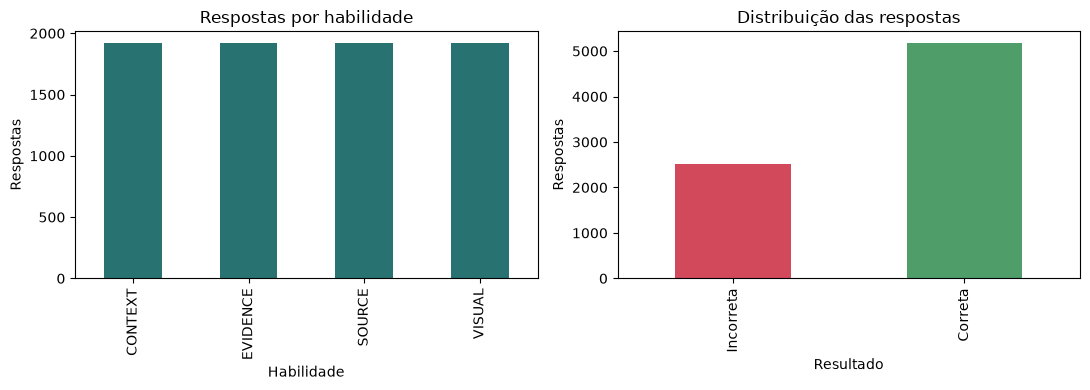

In [4]:
print('Distribuição de respostas:')
display(interactions['correct'].value_counts(normalize=True).rename(index={0: 'incorreta', 1: 'correta'}).to_frame('proporção'))
sequence_sizes = interactions.groupby(['user_id', 'skill_code']).size()
print('Sequências por tamanho:', sequence_sizes.describe().round(2).to_dict())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
interactions['skill_code'].value_counts().sort_index().plot.bar(ax=axes[0], color='#287271')
axes[0].set(title='Respostas por habilidade', xlabel='Habilidade', ylabel='Respostas')
interactions['correct'].value_counts().sort_index().rename(index={0: 'Incorreta', 1: 'Correta'}).plot.bar(ax=axes[1], color=['#d1495b', '#4f9d69'])
axes[1].set(title='Distribuição das respostas', xlabel='Resultado', ylabel='Respostas')
plt.tight_layout()
plt.show()

## Separação temporal e ajuste

Cada par aprendiz/habilidade é ordenado cronologicamente. Para sequências com pelo menos cinco observações, usamos o prefixo de 80% (mínimo três respostas) no ajuste e reservamos a cauda para avaliação; sequências curtas são excluídas. A verossimilhança é calculada sobre respostas Bernoulli previstas pelo estado BKT antes de observar cada resposta. Os parâmetros são ajustados globalmente por máxima verossimilhança, com limites para evitar probabilidades degeneradas.

In [5]:
MIN_SEQUENCE_LENGTH = 5
MIN_TRAIN_LENGTH = 3
train_sequences, test_sequences = [], []
excluded_sequences = 0
for _, group in interactions.groupby(['user_id', 'skill_code'], sort=False):
    outcomes = group['correct'].to_numpy(dtype=int)
    if len(outcomes) < MIN_SEQUENCE_LENGTH:
        excluded_sequences += 1
        continue
    split_at = min(max(int(np.floor(0.8 * len(outcomes))), MIN_TRAIN_LENGTH), len(outcomes) - 1)
    train_sequences.append(outcomes[:split_at])
    test_sequences.append((outcomes[:split_at], outcomes[split_at:]))
if not train_sequences or not any(len(test) for _, test in test_sequences):
    raise ValueError('Não há sequências suficientes para treino e holdout temporal. Forneça dados com pelo menos 5 respostas por aprendiz/habilidade.')
print(f'Sequências treino/holdout: {len(train_sequences)}; sequências excluídas por curta duração: {excluded_sequences}')
print(f'Respostas treino: {sum(map(len, train_sequences)):,}; respostas holdout: {sum(len(test) for _, test in test_sequences):,}')

PARAMETER_NAMES = ['p_init', 'p_guess', 'p_slip', 'p_transition']
BOUNDS = [(0.01, 0.99), (0.01, 0.40), (0.01, 0.40), (0.001, 0.50)]

def probability_correct(mastery, p_guess, p_slip):
    return mastery * (1 - p_slip) + (1 - mastery) * p_guess

def negative_log_likelihood(values, sequences):
    p_init, p_guess, p_slip, p_transition = values
    engine = BKTEngine(p_init=p_init, p_guess=p_guess, p_slip=p_slip, p_transition=p_transition)
    total_loss = 0.0
    for outcomes in sequences:
        mastery = p_init
        for outcome in outcomes:
            p_correct = float(np.clip(probability_correct(mastery, p_guess, p_slip), 1e-12, 1 - 1e-12))
            total_loss -= np.log(p_correct if outcome else 1 - p_correct)
            mastery = engine.update(mastery, bool(outcome))
    return float(total_loss)

initial_values = [0.30, 0.20, 0.05, 0.10]
fit_result = minimize(negative_log_likelihood, initial_values, args=(train_sequences,), method='L-BFGS-B', bounds=BOUNDS)
if not fit_result.success or not np.isfinite(fit_result.fun):
    raise RuntimeError(f'Otimização BKT não convergiu: {fit_result.message}')
fitted_params = dict(zip(PARAMETER_NAMES, map(float, fit_result.x)))
fitted_engine = BKTEngine(**fitted_params)
print('Convergência:', fit_result.message)
print('NLL no treino:', round(float(fit_result.fun), 3))
pd.Series(fitted_params, name='parâmetro calibrado').to_frame()

Sequências treino/holdout: 480; sequências excluídas por curta duração: 0
Respostas treino: 5,760; respostas holdout: 1,920
Convergência: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
NLL no treino: 2680.495


,parâmetro calibrado
p_init,0.282627
p_guess,0.196476
p_slip,0.055099
p_transition,0.102018


In [6]:
# Verificação de paridade com o teste unitário do repositório.
reference_engine = BKTEngine(p_guess=0.20, p_slip=0.05, p_transition=0.10)
reference_value = reference_engine.update(0.30, correct=True)
assert np.isclose(reference_value, 0.7035294118, atol=1e-9)
print(f'BKTEngine real: update(0.30, correta) = {reference_value:.10f}; referência do teste confirmada.')
print('Instância calibrada:', fitted_engine.get_parameters())

BKTEngine real: update(0.30, correta) = 0.7035294118; referência do teste confirmada.
Instância calibrada: {'p_guess': 0.19647559544587084, 'p_slip': 0.05509863454929375, 'p_transition': 0.10201783893454465, 'p_init': 0.2826265894338844}


## Avaliação sequencial

No holdout, cada probabilidade é prevista antes de observar o rótulo daquela tentativa. O estado é então atualizado com a resposta observada, como no uso online do backend. Comparamos os parâmetros calibrados com os defaults atuais do repositório. Log-loss e Brier avaliam probabilidades; acurácia usa limiar 0,5; AUC é omitida (`NaN`) se o holdout tiver apenas uma classe. Como os dados locais são sintéticos, qualquer número exibido abaixo serve somente para validar o pipeline.

In [7]:
DEFAULT_PARAMS = {'p_init': 0.30, 'p_guess': 0.20, 'p_slip': 0.05, 'p_transition': 0.10}

def collect_holdout_predictions(params, sequences):
    engine = BKTEngine(**params)
    labels, probabilities = [], []
    for train_part, test_part in sequences:
        mastery = params['p_init']
        for outcome in train_part:
            mastery = engine.update(mastery, bool(outcome))
        for outcome in test_part:
            probabilities.append(probability_correct(mastery, params['p_guess'], params['p_slip']))
            labels.append(int(outcome))
            mastery = engine.update(mastery, bool(outcome))
    return np.asarray(labels, dtype=int), np.clip(np.asarray(probabilities, dtype=float), 1e-12, 1 - 1e-12)

def rank_auc(labels, probabilities):
    positives = labels == 1
    n_positive, n_negative = int(positives.sum()), int((~positives).sum())
    if n_positive == 0 or n_negative == 0:
        return float('nan')
    ranks = pd.Series(probabilities).rank(method='average').to_numpy()
    return float((ranks[positives].sum() - n_positive * (n_positive + 1) / 2) / (n_positive * n_negative))

def calculate_metrics(labels, probabilities):
    return {
        'log_loss': float(-np.mean(labels * np.log(probabilities) + (1 - labels) * np.log(1 - probabilities))),
        'brier_score': float(np.mean((probabilities - labels) ** 2)),
        'accuracy@0.5': float(np.mean((probabilities >= 0.5) == labels)),
        'roc_auc': rank_auc(labels, probabilities),
    }

labels, calibrated_predictions = collect_holdout_predictions(fitted_params, test_sequences)
baseline_labels, baseline_predictions = collect_holdout_predictions(DEFAULT_PARAMS, test_sequences)
assert np.array_equal(labels, baseline_labels)
metrics = pd.DataFrame({
    'BKT calibrado': calculate_metrics(labels, calibrated_predictions),
    'Defaults do backend': calculate_metrics(labels, baseline_predictions),
}).T
print(f'Holdout: {len(labels):,} respostas; corretas={int(labels.sum()):,}; incorretas={int((1-labels).sum()):,}')
metrics

Holdout: 1,920 respostas; corretas=1,589; incorretas=331


,log_loss,brier_score,accuracy@0.5,roc_auc
BKT calibrado,0.294327,0.085447,0.886458,0.855811
Defaults do backend,0.293980,0.085403,0.886458,0.855640


## Persistência do modelo

O pickle guarda um dicionário simples com schema versionado, parâmetros, origem e métricas; não serializa uma classe customizada. O arquivo é `backend/models/bkt_trained.pkl` para dados reais ou `backend/models/bkt_demo.pkl` para demonstração. **Não implante o artefato demo.** Pickle pode executar código ao ser carregado: carregue somente arquivos de fonte confiável.

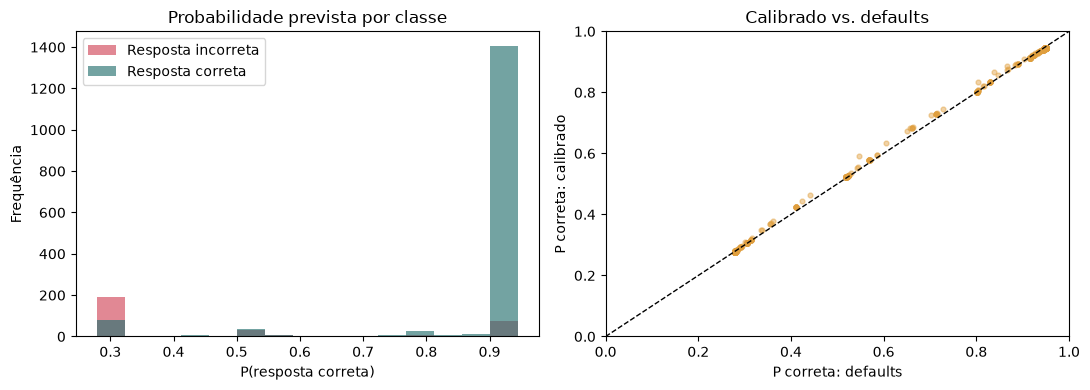

Artefato salvo e recarregado: backend/models/bkt_demo.pkl
Origem: synthetic_demo (seed=20261009) | dados reais: False
Probabilidade de acerto em mastery=0.30: 0.421
ARTEFATO DE DEMONSTRAÇÃO: não utilizar para decisões sobre usuários nem implantar.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(calibrated_predictions[labels == 0], bins=15, alpha=0.65, label='Resposta incorreta', color='#d1495b')
axes[0].hist(calibrated_predictions[labels == 1], bins=15, alpha=0.65, label='Resposta correta', color='#287271')
axes[0].set(title='Probabilidade prevista por classe', xlabel='P(resposta correta)', ylabel='Frequência')
axes[0].legend()
axes[1].scatter(baseline_predictions, calibrated_predictions, s=12, alpha=0.45, color='#e09f3e')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
axes[1].set(title='Calibrado vs. defaults', xlabel='P correta: defaults', ylabel='P correta: calibrado', xlim=(0, 1), ylim=(0, 1))
plt.tight_layout()
plt.show()

def json_safe_metrics(metric_frame):
    safe = {}
    for model_name, row in metric_frame.iterrows():
        safe[model_name] = {key: (None if pd.isna(value) else float(value)) for key, value in row.items()}
    return safe

artifact = {
    'schema_version': 1,
    'model_type': 'Bayesian Knowledge Tracing',
    'parameters': fitted_params,
    'data_source': DATA_SOURCE,
    'is_real_data': bool(IS_REAL_DATA),
    'trained_at_utc': datetime.now(timezone.utc).isoformat(),
    'training_method': 'maximum likelihood (L-BFGS-B), pooled learner-skill sequences',
    'split': 'chronological 80/20 per learner-skill sequence; minimum 5 observations',
    'metrics': json_safe_metrics(metrics),
    'n_training_sequences': len(train_sequences),
    'n_holdout_responses': int(len(labels)),
    'implementation': 'backend/app/bkt/engine.py',
}
artifact_dir = REPO_ROOT / 'backend' / 'models'
artifact_dir.mkdir(parents=True, exist_ok=True)
artifact_path = artifact_dir / ('bkt_trained.pkl' if IS_REAL_DATA else 'bkt_demo.pkl')
with artifact_path.open('wb') as model_file:
    pickle.dump(artifact, model_file, protocol=pickle.HIGHEST_PROTOCOL)

with artifact_path.open('rb') as model_file:
    loaded_artifact = pickle.load(model_file)
assert loaded_artifact['schema_version'] == 1
loaded_engine = BKTEngine(**loaded_artifact['parameters'])
loaded_probability = probability_correct(0.30, loaded_engine.p_guess, loaded_engine.p_slip)
print('Artefato salvo e recarregado:', artifact_path.relative_to(REPO_ROOT))
print('Origem:', loaded_artifact['data_source'], '| dados reais:', loaded_artifact['is_real_data'])
print('Probabilidade de acerto em mastery=0.30:', round(loaded_probability, 4))
if not IS_REAL_DATA:
    print('ARTEFATO DE DEMONSTRAÇÃO: não utilizar para decisões sobre usuários nem implantar.')
else:
    print('Revise validação, tamanho e representatividade dos dados antes de implantação.')

## Interpretação e próximos passos

A calibração global pressupõe que as quatro habilidades compartilham parâmetros, como ocorre nos defaults atuais. Com volume suficiente, compare também calibração por habilidade. O holdout temporal mede previsão da próxima resposta após histórico conhecido; não prova causalidade da aprendizagem nem valida mastery contra uma avaliação externa. Antes de produção, use dados reais consentidos, avalie por coortes e período futuro, examine calibração/estabilidade e compare com defaults. O backend atual não carrega este pickle: integrar os parâmetros exige definir política de carregamento e versionamento nos trackers.